---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 3. Вольт-амперна характеристика діода. Пробій і перехідні процеси</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Ідеалізована ВАХ p-n переходу (рівняння Шоклі)</li>
  <li>Відмінності реальної ВАХ: рекомбінація, високий рівень інжекції, опір бази, струм генерації</li>
  <li>Вплив температури на ВАХ діода</li>
  <li>Пробій p-n переходу: тунельний, лавинний, тепловий</li>
  <li>Перехідні процеси: відновлення зворотного опору</li>
  <li>Моделі діода та графоаналітичний розрахунок кола з діодом</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 3 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Ідеалізована вольт-амперна характеристика](#ideal-iv)
* [Реальна ВАХ: пряма гілка](#real-forward)
    * [⚙️ PySpice: з чого складається пряма гілка реального діода](#spice-forward)
* [Реальна ВАХ: зворотна гілка](#real-reverse)
* [Вплив температури](#temperature)
    * [⚙️ PySpice: ВАХ діода 1N4148 при різних температурах](#spice-temperature)
* [Пробій p-n переходу](#breakdown)
    * [Тунельний пробій](#tunnel-breakdown)
    * [Лавинний пробій](#avalanche-breakdown)
    * [Тепловий пробій](#thermal-breakdown)
* [Перехідні процеси в діоді](#switching)
    * [⚙️ PySpice: відновлення зворотного опору 1N4007, 1N5819, 1N4148](#spice-recovery)
* [Моделі діода. Розрахунок кола з діодом](#diode-models)
    * [⚙️ PySpice: робоча точка діода на навантажувальній прямій](#spice-loadline)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

def diode_dc(model_lines, U_start, U_stop, step, T=27.0, gmin=None, include=None):
    """DC-розгортка діода, підключеного до джерела напруги. Повертає (U, I).
    model_lines: dict параметрів для circuit.model або назва моделі з бібліотеки include"""
    c = Circuit('Diode DC sweep')
    if include:
        c.include(lib(include)); mname = model_lines
    else:
        c.model('DX', 'D', **model_lines); mname = 'DX'
    c.V('d', 'a', c.gnd, 0)
    c.D('1', 'a', c.gnd, model=mname)
    sim = c.simulator(temperature=T, nominal_temperature=27)
    if gmin: sim.options(gmin=gmin)
    an = sim.dc(Vd=slice(U_start, U_stop, step))
    return np.array(an.sweep), -np.array(an.branches['vd'])

---

# Ідеалізована вольт-амперна характеристика <a class="anchor" id="ideal-iv"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати і пояснювати рівняння Шоклі, оцінювати струм насичення за параметрами переходу
> - Пояснювати відхилення реальної ВАХ від ідеальної на прямій і зворотній гілках
> - Оцінювати температурні зміни прямої напруги і зворотного струму
> - Розрізняти тунельний, лавинний і тепловий пробій за фізикою, напругою і знаком ТКН
> - Пояснювати процес відновлення зворотного опору і оцінювати час розсмоктування
> - Обирати модель діода для розрахунку кола і знаходити робочу точку графоаналітично

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Струм насичення $I_S$** | Зворотний струм ідеального переходу, пропорційний $n_i^2$; для Si — $10^{-15}$–$10^{-9}$ А |
| **Коефіцієнт неідеальності $n$** | Множник у показнику експоненти $e^{U/n\varphi_T}$: 1 — дифузія, 2 — рекомбінація в ОПЗ або високий рівень інжекції |
| **Диференціальний опір $r_д$** | $r_д = dU/dI = n\varphi_T/I$ — опір діода для малого змінного сигналу |
| **ТКН** | Температурний коефіцієнт напруги, $dU/dT$; для прямої гілки Si ≈ −2 мВ/К |
| **Напруга пробою $U_{проб}$** | Зворотна напруга, при якій струм різко зростає |
| **Час відновлення $t_{вв}$ ($t_{rr}$)** | Час, за який діод після перемикання з прямого струму на зворотну напругу відновлює запірні властивості |

Модель **Шоклі** враховує лише дифузію неосновних носіїв у нейтральних областях. Закон переходу задає надлишкову концентрацію на межах ОПЗ, $p_n(x_n) - p_{n0} = p_{n0}(e^{U/\varphi_T} - 1)$, яка далі спадає вглиб бази експоненційно з дифузійною довжиною $L_p$. Дифузійний струм на межі $j = qD_p\,\Delta p/L_p$; додавши такий самий внесок електронів у p-області, отримуємо **рівняння ідеального діода**:

$$I = I_S\left(e^{U/\varphi_T} - 1\right), \qquad I_S = qS\,n_i^2\left(\frac{D_p}{L_pN_d} + \frac{D_n}{L_nN_a}\right).$$

- Струм насичення визначається **слабше легованою** областю (для $p^+$–$n$ діода — базою n-типу) і пропорційний $n_i^2$ — тому $I_S$ германієвих діодів на 6 порядків більший, ніж кремнієвих.
- При $U \gg \varphi_T$ струм зростає в $e$ разів на кожні 25,85 мВ, тобто **в 10 разів на кожні 59,5 мВ** (≈60 мВ/декаду).
- При $U < -3\varphi_T$ струм насичується: $I \to -I_S$.
- **Диференціальний опір** $r_д = dU/dI = \varphi_T/(I + I_S) \approx \varphi_T/I$: при 1 мА він дорівнює 26 Ом, при 10 мА — 2,6 Ом.

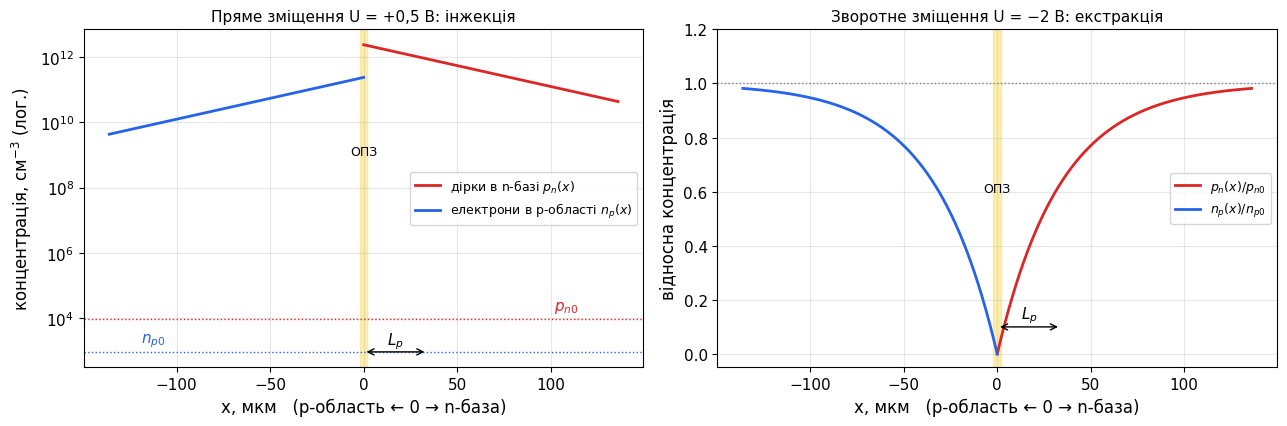

In [2]:
# Розподіл неосновних носіїв у базах p+-n... (Na = 1e17, Nd = 1e16, L = 34 мкм) при прямому та зворотному зміщенні
pT = phi_T(300); ni = 9.65e9; Na, Nd, L = 1e17, 1e16, 34.0
pn0, np0 = ni**2/Nd, ni**2/Na
xr = np.linspace(0, 4*L, 400); xl = -xr
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, U, ttl in [(axes[0], 0.5, 'Пряме зміщення U = +0,5 В: інжекція'), (axes[1], -2.0, 'Зворотне зміщення U = −2 В: екстракція')]:
    pn = pn0 + pn0*(np.exp(U/pT) - 1)*np.exp(-xr/L)
    npp = np0 + np0*(np.exp(U/pT) - 1)*np.exp(xl/L)
    if U > 0:
        ax.semilogy(xr, pn, color='#dc2626', label='дірки в n-базі $p_n(x)$'); ax.semilogy(xl, npp, color='#2563eb', label='електрони в p-області $n_p(x)$')
        ax.axhline(pn0, color='#dc2626', ls=':', lw=1); ax.axhline(np0, color='#2563eb', ls=':', lw=1)
        ax.text(3*L, pn0*2, '$p_{n0}$', color='#dc2626'); ax.text(-3.5*L, np0*2, '$n_{p0}$', color='#2563eb')
        ax.set_ylabel('концентрація, см$^{-3}$ (лог.)')
    else:
        ax.plot(xr, pn/pn0, color='#dc2626', label='$p_n(x)/p_{n0}$'); ax.plot(xl, npp/np0, color='#2563eb', label='$n_p(x)/n_{p0}$')
        ax.axhline(1, color='gray', ls=':', lw=1); ax.set_ylim(-0.05, 1.2)
        ax.set_ylabel('відносна концентрація')
    ax.axvspan(-2, 2, color='#fde68a', alpha=0.7); ax.text(0, ax.get_ylim()[1]*0.5 if U < 0 else 1e9, 'ОПЗ', ha='center', fontsize=9)
    ax.annotate('', xy=(L, ax.get_ylim()[0]*3 if U > 0 else 0.1), xytext=(0, ax.get_ylim()[0]*3 if U > 0 else 0.1),
                arrowprops=dict(arrowstyle='<->'))
    ax.text(L/2, (ax.get_ylim()[0]*5) if U > 0 else 0.13, '$L_p$', ha='center')
    ax.set_xlabel('x, мкм   (p-область ← 0 → n-база)'); ax.set_title(ttl, fontsize=11); ax.legend(fontsize=9, loc='center right')
plt.tight_layout(); plt.show()

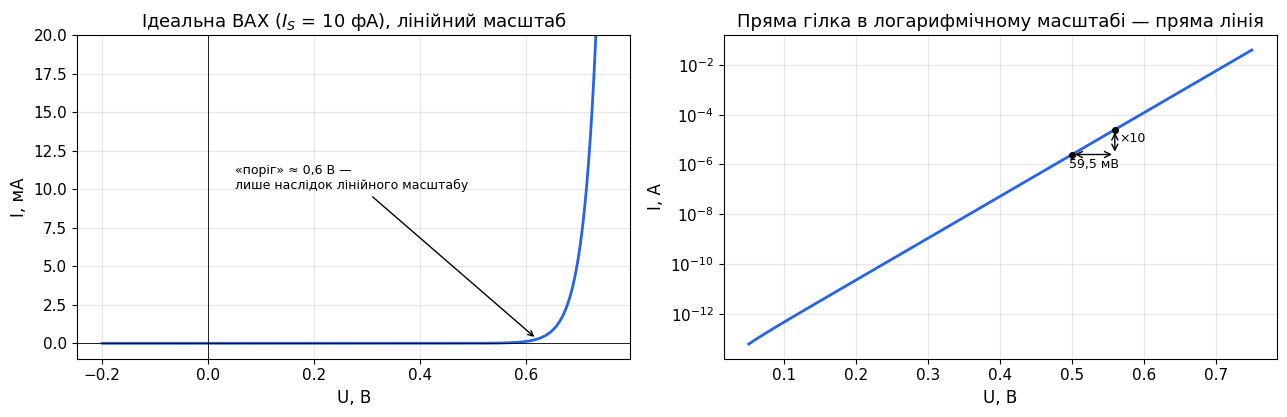

In [3]:
Is = 1e-14
U = np.linspace(-0.2, 0.75, 2000)
I = Is*(np.exp(U/phi_T(300)) - 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(U, I*1e3, color='#2563eb'); axes[0].set_ylim(-1, 20); axes[0].axhline(0, color='k', lw=0.6); axes[0].axvline(0, color='k', lw=0.6)
axes[0].set_xlabel('U, В'); axes[0].set_ylabel('I, мА'); axes[0].set_title('Ідеальна ВАХ ($I_S$ = 10 фА), лінійний масштаб')
axes[0].annotate('«поріг» ≈ 0,6 В —\nлише наслідок лінійного масштабу', xy=(0.62, 0.3), xytext=(0.05, 10),
                 arrowprops=dict(arrowstyle='->'), fontsize=9)
m = U > 0.05
axes[1].semilogy(U[m], I[m], color='#2563eb'); axes[1].set_xlabel('U, В'); axes[1].set_ylabel('I, А')
for u0 in [0.5, 0.5595]:
    axes[1].plot([u0], [Is*np.exp(u0/phi_T(300))], 'ko', ms=4)
axes[1].annotate('', xy=(0.5595, Is*np.exp(0.5/phi_T(300))), xytext=(0.5, Is*np.exp(0.5/phi_T(300))), arrowprops=dict(arrowstyle='<->'))
axes[1].text(0.53, Is*np.exp(0.5/phi_T(300))*0.3, '59,5 мВ', ha='center', fontsize=9)
axes[1].annotate('', xy=(0.5595, Is*np.exp(0.5595/phi_T(300))), xytext=(0.5595, Is*np.exp(0.5/phi_T(300))), arrowprops=dict(arrowstyle='<->'))
axes[1].text(0.565, Is*np.exp(0.53/phi_T(300)), '×10', fontsize=9)
axes[1].set_title('Пряма гілка в логарифмічному масштабі — пряма лінія'); axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

«Кремнієвий діод відкривається при 0,6–0,7 В, а до того струм дорівнює нулю» — неточно. Експонента не має «порога»: при 0,4 В струм діода з $I_S = 10$ фА дорівнює ≈50 нА, при 0,5 В — ≈2,5 мкА, при 0,6 В — ≈0,1 мА. «Поріг» 0,6–0,7 В — це напруга, при якій струм досягає значень, помітних **у лінійному масштабі** типової схеми (міліампери). Для мікрострумових схем (годинники, датчики) діод «відкритий» уже при 0,3–0,4 В.

</div>

---

# Реальна ВАХ: пряма гілка <a class="anchor" id="real-forward"></a>

У реальному діоді на пряму гілку, окрім дифузії (модель Шоклі), впливають ще три ефекти — кожен домінує у своєму діапазоні струмів:

1. **Рекомбінація в ОПЗ** (малі струми). Частина інжектованих носіїв рекомбінує прямо в збідненому шарі через пастки. Цей струм пропорційний $n_i$ (а не $n_i^2$) і зростає як $e^{U/2\varphi_T}$ (**$n \approx 2$**, 120 мВ/декаду). У кремнієвих діодах саме він переважає при струмах нижче мікроамперів.
2. **Високий рівень інжекції** (великі струми). Коли концентрація інжектованих носіїв у базі порівнюється з концентрацією основних, частина напруги падає на базі, і нахил знову зменшується до **$n \approx 2$** (у SPICE — параметр `IKF`).
3. **Об'ємний опір бази й контактів $R_s$** (найбільші струми). Напруга на переході $U_п = U - IR_s$; ВАХ «загинається» і стає майже лінійною: $U \approx U_п + IR_s$.

Загальну ВАХ часто апроксимують рівнянням $I = I_S\left(e^{(U - IR_s)/n\varphi_T} - 1\right)$ з емпіричним $n = 1$–$2$.

### ⚙️ PySpice: з чого складається пряма гілка реального діода <a class="anchor" id="spice-forward"></a>

Модель діода ngspice містить усі ці механізми: `IS`, `N` — дифузійний струм; `ISR`, `NR` — рекомбінаційний; `IKF` — високий рівень інжекції; `RS` — опір бази. Вмикайте ефекти по одному й спостерігайте, як змінюється пряма гілка в логарифмічному масштабі. Пунктир — ідеальна модель Шоклі.

In [4]:
def forward_effects(recombination=True, high_injection=True, series_R=True):
    p = dict(IS=1e-14, N=1.0)
    if recombination: p.update(ISR=1e-11, NR=2.0)
    if high_injection: p.update(IKF=0.05)
    if series_R: p.update(RS=0.5)
    U, I = diode_dc(p, 0.0, 1.2, 0.002)
    Ui = np.linspace(0.05, 1.2, 500)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.semilogy(Ui, 1e-14*(np.exp(Ui/phi_T()) - 1), 'k--', lw=1.2, label='Шоклі: $I_S = 10$ фА, $n = 1$')
    ax.semilogy(U, np.clip(I, 1e-15, None), color='#dc2626', lw=2.5, label='ngspice: реальний діод')
    if recombination:
        ax.semilogy(Ui, 1e-11*np.exp(Ui/(2*phi_T())), ':', color='#7c3aed', lw=1.3, label='рекомбінація в ОПЗ, $n = 2$')
        ax.annotate('рекомбінація в ОПЗ\n(n ≈ 2)', xy=(0.2, 1e-11*np.exp(0.2/(2*phi_T()))), xytext=(0.03, 1e-7),
                    color='#7c3aed', fontsize=9, arrowprops=dict(arrowstyle='->', color='#7c3aed'))
    ax.annotate('дифузія (n = 1)', xy=(0.5, 1e-14*np.exp(0.5/phi_T())), xytext=(0.52, 1e-10), fontsize=9,
                arrowprops=dict(arrowstyle='->'))
    if high_injection:
        ax.annotate('високий рівень\nінжекції', xy=(0.74, 1.2e-2), xytext=(0.72, 1e-5), color='#b45309', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='#b45309'))
    if series_R:
        ax.annotate('опір бази $R_s$', xy=(1.05, 0.33), xytext=(0.9, 5e-3), color='#16a34a', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='#16a34a'))
    ax.set_ylim(1e-13, 3); ax.set_xlim(0, 1.2); ax.grid(True, which='both', alpha=0.3)
    ax.set_xlabel('U, В'); ax.set_ylabel('I, А'); ax.legend(fontsize=9, loc='lower right')
    ax.set_title('Пряма гілка ВАХ: внесок різних механізмів (ngspice)')
    plt.tight_layout(); plt.show()
    for Iq in [1e-9, 1e-6, 1e-3, 0.1]:
        k = np.argmin(abs(np.log(np.clip(I, 1e-20, None)) - np.log(Iq)))
        print(f'I = {Iq:.0e} A:  U = {U[k]:.3f} В   (за Шоклі {phi_T()*np.log(Iq/1e-14):.3f} В)')

interact(forward_effects,
         recombination=widgets.Checkbox(value=True, description='рекомбінація в ОПЗ (ISR, NR)'),
         high_injection=widgets.Checkbox(value=True, description='високий рівень інжекції (IKF)'),
         series_R=widgets.Checkbox(value=True, description='опір бази RS = 0,5 Ом'));

interactive(children=(Checkbox(value=True, description='рекомбінація в ОПЗ (ISR, NR)'), Checkbox(value=True, d…

---

# Реальна ВАХ: зворотна гілка <a class="anchor" id="real-reverse"></a>

Реальний зворотний струм кремнієвого діода **набагато більший** за $I_S$ і повільно зростає з напругою. Причини:

1. **Струм термогенерації в ОПЗ.** Пари електрон–дірка, що генеруються через пастки прямо в збідненому шарі, одразу розділяються полем:
$$I_{ген} = \frac{qn_iWS}{2\tau} \propto \sqrt{\varphi_к + |U|}.$$
Оскільки він пропорційний $n_i$, а не $n_i^2$, для кремнію при кімнатній температурі $I_{ген}$ перевищує $I_S$ на 4–6 порядків. Саме він визначає паспортний зворотний струм кремнієвих діодів.
2. **Поверхневі струми витоку** — провідність уздовж поверхні кристала, чутлива до забруднень і вологи; лінійно зростають з напругою.
3. **Лавинне множення** біля напруги пробою: струм помножується на коефіцієнт $M = 1/[1 - (|U|/U_{проб})^m]$.

Для германієвих діодів, навпаки, $I_S$ великий і переважає, тому їхня зворотна гілка ближча до ідеальної.

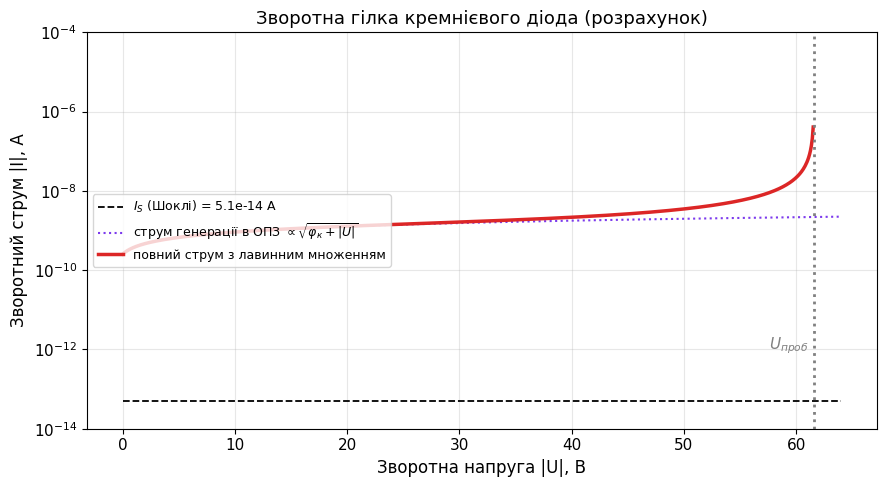

I_S = 5.09e-14 A;  I_ген(U=0) = 2.53e-10 A;  I_ген(50 В) = 1.98e-09 A;  I_ген/I_S ≈ 5e+03


In [5]:
# Зворотна гілка p+-n діода (S = 1 мм^2, Nd = 1e16, tau = 1 мкс): дифузійний струм, генерація в ОПЗ, лавинне множення
S, tau, Nd, ni = 1e-2, 1e-6, 1e16, 9.65e9
eps = 11.7*eps0*1e-2
phik = 0.83
Dp = 450*phi_T(); Lp = np.sqrt(Dp*tau)
Is = q*S*ni**2*Dp/(Lp*Nd)
Ur = np.linspace(0, 64, 800)
W = np.sqrt(2*eps*(phik + Ur)/(q*Nd))
Igen = q*ni*W*S/(2*tau)
UBR = 61.6; M = 1/(1 - (Ur/UBR)**4); M[Ur >= UBR*0.9995] = np.nan
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(Ur, np.full_like(Ur, Is), 'k--', lw=1.3, label=f'$I_S$ (Шоклі) = {Is:.1e} А')
ax.semilogy(Ur, Igen, color='#7c3aed', lw=1.5, ls=':', label='струм генерації в ОПЗ $\\propto\\sqrt{\\varphi_к+|U|}$')
ax.semilogy(Ur, (Is + Igen)*M, color='#dc2626', lw=2.5, label='повний струм з лавинним множенням')
ax.axvline(UBR, color='gray', ls=':'); ax.text(UBR - 0.5, 1e-12, '$U_{проб}$', ha='right', color='gray')
ax.set_xlabel('Зворотна напруга |U|, В'); ax.set_ylabel('Зворотний струм |I|, А')
ax.set_title('Зворотна гілка кремнієвого діода (розрахунок)'); ax.legend(fontsize=9, loc='center left')
ax.set_ylim(1e-14, 1e-4); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'I_S = {Is:.2e} A;  I_ген(U=0) = {Igen[0]:.2e} A;  I_ген(50 В) = {Igen[np.argmin(abs(Ur-50))]:.2e} A;'
      f'  I_ген/I_S ≈ {Igen[0]/Is:.0e}')

---

# Вплив температури <a class="anchor" id="temperature"></a>

**Зворотний струм** зростає з температурою дуже швидко: тепловий $I_S \propto n_i^2 \propto T^3e^{-E_g/kT}$ — приблизно на 15 %/К (подвоюється кожні ≈5 К), генераційний $I_{ген} \propto n_i$ — на ≈8 %/К (подвоюється кожні ≈9 К). Практичне правило: **зворотний струм кремнієвого діода подвоюється кожні 8–10 °C**.

**Пряма напруга** при сталому струмі **зменшується**. З рівняння Шоклі $U = \varphi_T\ln(I/I_S)$ і швидкого зростання $I_S(T)$:

$$\frac{dU}{dT}\bigg|_{I=\text{const}} = -\frac{E_g/q + 3\varphi_T - U}{T} \approx -\frac{1{,}2 + 0{,}08 - 0{,}65}{300} \approx -2\ \text{мВ/К}.$$

Цю лінійну залежність використовують у **напівпровідникових датчиках температури** (діод або перехід база–емітер транзистора при сталому струмі) — вони вбудовані у мікропроцесори, АЦП, стабілізатори.

### ⚙️ PySpice: ВАХ діода 1N4148 при різних температурах <a class="anchor" id="spice-temperature"></a>

Модель 1N4148 з теки `models/` (параметри `EG`, `XTI` задають температурну залежність). Повзунок задає струм, при якому оцінюється ТКН прямої напруги.

In [6]:
TEMPS = [-40, 0, 27, 85, 125]
curves = {T: diode_dc('D1N4148', 0.0, 1.0, 0.002, T=T, include='diodes') for T in TEMPS}

def temp_plot(I_mA=1.0, log_scale=True):
    fig, ax = plt.subplots(figsize=(9, 5))
    cmap = plt.get_cmap('coolwarm')
    Uop = []
    for k, T in enumerate(TEMPS):
        U, I = curves[T]
        col = cmap(k/(len(TEMPS) - 1))
        (ax.semilogy if log_scale else ax.plot)(U, I*1e3 if not log_scale else I, color=col, label=f'{T:+d} °C')
        Uop.append(np.interp(np.log(I_mA*1e-3), np.log(np.clip(I, 1e-18, None)), U))
    y = I_mA*1e-3 if log_scale else I_mA
    ax.axhline(y, color='gray', ls=':', lw=1)
    ax.plot(Uop, [y]*len(Uop), 'ko', ms=4)
    if log_scale: ax.set_ylim(1e-9, 0.3); ax.set_ylabel('I, А'); ax.grid(True, which='both', alpha=0.3)
    else: ax.set_ylim(0, 20); ax.set_ylabel('I, мА')
    ax.set_xlabel('U, В'); ax.set_title('Пряма гілка ВАХ 1N4148 при різних температурах (ngspice)')
    ax.legend(title='T', fontsize=9)
    plt.tight_layout(); plt.show()
    tc = np.polyfit(TEMPS, Uop, 1)[0]*1e3
    print('Пряма напруга при I = %.2g мА: ' % I_mA + ',  '.join(f'{T:+d} °C: {u:.3f} В' for T, u in zip(TEMPS, Uop)))
    print(f'ТКН = dU/dT ≈ {tc:.2f} мВ/°C')

interact(temp_plot, I_mA=widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=1.7, step=0.1, description='I, мА',
                                                continuous_update=False),
         log_scale=widgets.Checkbox(value=True, description='логарифмічний масштаб'));

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='I, мА', max=1.7, min=-2.…

---
### ✅ Питання для самоперевірки: ВАХ діода та вплив температури

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> На скільки треба збільшити пряму напругу ідеального діода, щоб струм зріс у 100 разів?</summary>

> **Відповідь:** На $\varphi_T\ln100 = 2\cdot59{,}5 \approx 119$ мВ (60 мВ на кожну декаду струму).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому зворотний струм кремнієвого діода не дорівнює $I_S$ з рівняння Шоклі?</summary>

> **Відповідь:** Бо в кремнії переважає струм термогенерації в ОПЗ ($\propto n_i$, а не $n_i^2$), до того ж зростаючий з напругою через розширення ОПЗ; додаються поверхневі витоки. У Si він на кілька порядків більший за $I_S$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому пряма напруга діода при сталому струмі зменшується з ростом температури?</summary>

> **Відповідь:** Струм насичення $I_S \propto T^3e^{-E_g/kT}$ зростає дуже швидко, тому той самий струм $I = I_S e^{U/\varphi_T}$ досягається при меншій $U$. Результат — ТКН ≈ −2 мВ/К.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Що означає коефіцієнт неідеальності $n = 2$ на ділянці малих струмів?</summary>

> **Відповідь:** Переважає рекомбінація носіїв у ОПЗ через пастки: її швидкість пропорційна $n_ie^{U/2\varphi_T}$, тому нахил ВАХ — 120 мВ/декаду.

</details>

---

# Пробій p-n переходу <a class="anchor" id="breakdown"></a>

**Пробоєм** називають різке зростання зворотного струму при досягненні певної зворотної напруги $U_{проб}$. Розрізняють **електричний** пробій (тунельний і лавинний) — оборотний, якщо обмежити струм і потужність, — і **тепловий** — зазвичай незворотний, бо закінчується руйнуванням кристала.

## Тунельний пробій <a class="anchor" id="tunnel-breakdown"></a>

У **сильно легованих** переходах ($N \gtrsim 10^{18}$ см⁻³) ОПЗ дуже вузька (≈10 нм), і вже при кількох вольтах поле досягає $10^6$ В/см. Зони згинаються так, що заповнені стани валентної зони p-області опиняються навпроти вільних станів зони провідності n-області, розділені тонким бар'єром. Електрони **тунелюють** крізь бар'єр без зміни енергії (ефект Зенера). Ознаки:

- низька напруга пробою: $U_{проб} < 4E_g/q$ (для Si менше ≈ 4,5–5 В);
- «м'яке» коліно ВАХ — тунельний струм зростає поступово;
- **від'ємний ТКН**: з нагріванням $E_g$ зменшується, бар'єр стає нижчим, тунелювання полегшується — $U_{проб}$ падає.

## Лавинний пробій <a class="anchor" id="avalanche-breakdown"></a>

У **помірно легованих** переходах ОПЗ широка. Носій, що перетинає ОПЗ, розганяється полем і на довжині вільного пробігу набирає енергію, достатню для **ударної іонізації** — розриву ковалентного зв'язку з утворенням нової пари. Нові носії теж розганяються — виникає **лавинне множення** з коефіцієнтом

$$M = \frac{1}{1 - \left(|U|/U_{проб}\right)^m}, \qquad m = 2\text{–}6.$$

Ознаки:

- висока напруга пробою: $U_{проб} > 6E_g/q$ (для Si понад ≈ 6,5–7 В); для різкого $p^+$–$n$ переходу $U_{проб} \approx 60\,(E_g/1{,}1)^{3/2}(N_d/10^{16})^{-3/4}$ В;
- **різке** коліно ВАХ;
- **додатний ТКН**: з нагріванням зростає розсіювання на фононах, довжина вільного пробігу скорочується, для набору енергії іонізації потрібне сильніше поле — $U_{проб}$ зростає.

У діапазоні 4–6 $E_g/q$ (для Si — приблизно 5–7 В) діють обидва механізми. Їхні ТКН мають протилежні знаки і частково компенсуються — тому стабілітрони на 5,6–6,2 В найбільш термостабільні.

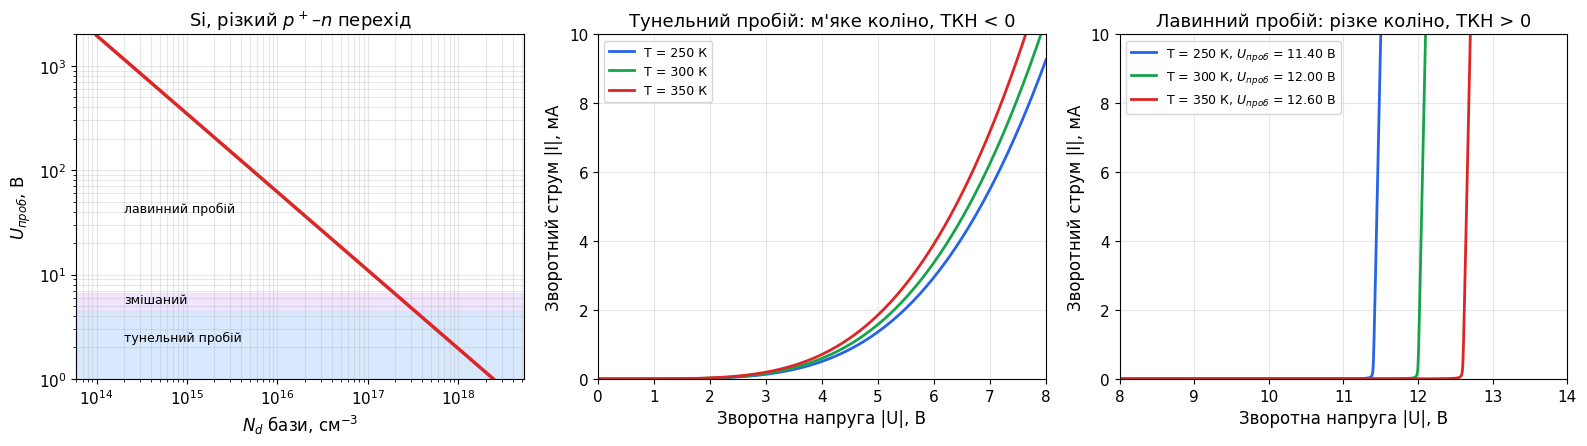

In [7]:
# (а) Напруга пробою різкого p+-n переходу в Si від легування бази; (б) характер пробою і вплив температури
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
N = np.logspace(14, 18.5, 300)
Ubr = 60*(1.12/1.1)**1.5*(N/1e16)**-0.75
ax = axes[0]
ax.loglog(N, Ubr, color='#dc2626', lw=2.5)
ax.axhspan(1, 4*1.12, color='#bfdbfe', alpha=0.6); ax.axhspan(4*1.12, 6*1.12, color='#e9d5ff', alpha=0.6)
ax.text(2e14, 2.3, 'тунельний пробій', fontsize=9); ax.text(2e14, 5.3, 'змішаний', fontsize=9); ax.text(2e14, 40, 'лавинний пробій', fontsize=9)
ax.set_ylim(1, 2000); ax.set_xlabel('$N_d$ бази, см$^{-3}$'); ax.set_ylabel('$U_{проб}$, В'); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Si, різкий $p^+$–$n$ перехід')

def Eg_Si(T): return 1.1695 - 4.73e-4*T**2/(T + 636)
Ur = np.linspace(0, 16, 1500)
cols = {250: '#2563eb', 300: '#16a34a', 350: '#dc2626'}
for T in [250, 300, 350]:
    # тунельний: J ∝ E·exp(-b·Eg^1.5/E), E ∝ sqrt(U + φк); калібровано на 1 мА при 4,5 В і 300 К
    E = np.sqrt(Ur + 0.9); E0 = np.sqrt(4.5 + 0.9)
    b = 22.0
    It = 1e-3*(E/E0)*np.exp(-b*(Eg_Si(T)/Eg_Si(300))**1.5/E + b/E0)
    axes[1].plot(Ur, It*1e3, color=cols[T], label=f'T = {T} К')
    UBR = 12.0*(1 + 1.0e-3*(T - 300))                 # ТКН ≈ +0,1 %/К
    I0 = 1e-6; Ia = np.logspace(-9, np.log10(10e-3), 600)                   # I = I0·M(U)  →  U(I) + I·r_дин
    Ua = UBR*np.clip(1 - I0/np.maximum(Ia, I0*1.0000001), 0, 1)**(1/6) + Ia*10.0
    Ua[Ia < I0] = Ia[Ia < I0]/I0*UBR*0.5                                  # до множення — майже сталий струм
    axes[2].plot(Ua, Ia*1e3, color=cols[T], label=f'T = {T} К, $U_{{проб}}$ = {UBR:.2f} В')
axes[1].set_xlim(0, 8); axes[1].set_ylim(0, 10); axes[1].set_title('Тунельний пробій: м\'яке коліно, ТКН < 0')
axes[2].set_xlim(8, 14); axes[2].set_ylim(0, 10); axes[2].set_title('Лавинний пробій: різке коліно, ТКН > 0')
for ax in axes[1:]:
    ax.set_xlabel('Зворотна напруга |U|, В'); ax.set_ylabel('Зворотний струм |I|, мА'); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

## Тепловий пробій <a class="anchor" id="thermal-breakdown"></a>

Зворотний струм, як ми бачили, експоненційно зростає з температурою, а потужність $P = |U|I$ нагріває перехід: $T = T_0 + R_{th}P$, де $R_{th}$ — тепловий опір «перехід–середовище» (К/Вт). Виникає **додатний тепловий зворотний зв'язок**: нагрів → зростання струму → ще більший нагрів. Якщо тепловідвід не встигає відводити тепло, температура лавиноподібно зростає — **тепловий пробій**. На ВАХ з'являється ділянка з **від'ємним диференціальним опором**: струм зростає при спаданні напруги. Особливо схильні до теплового пробою прилади з великим зворотним струмом (германієві, потужні, гарячі) і з поганим тепловідводом. У розрахунку нижче $I_0$ — зворотний струм при температурі середовища (для потужних і германієвих діодів — десяті частки–одиниці мА).

In [8]:
def thermal_breakdown(Rth=100.0, I0_mA=0.5):
    alpha = np.log(2)/9.0              # зворотний струм подвоюється кожні 9 К
    I0 = I0_mA*1e-3
    dT = np.linspace(0, 6/alpha, 2000)             # перегрів переходу, К
    I = I0*np.exp(alpha*dT)
    U = dT/(Rth*I)                                  # з балансу тепла: dT = Rth·U·I
    k = np.argmax(U)
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.plot(U[:k+1], I[:k+1]*1e3, color='#16a34a', lw=2.5, label='стійка ділянка')
    ax.plot(U[k:], I[k:]*1e3, color='#dc2626', lw=2.5, ls='--', label='від\'ємний диф. опір (нестійка)')
    ax.plot(U[k], I[k]*1e3, 'ko'); ax.annotate(f'$U_{{т.проб}}$ = {U[k]:.0f} В,\nперегрів {dT[k]:.0f} К',
                                             xy=(U[k], I[k]*1e3), xytext=(U[k]*0.45, I[k]*1e3*25), arrowprops=dict(arrowstyle='->'))
    ax.set_xlabel('Зворотна напруга |U|, В'); ax.set_ylabel('|I|, мА'); ax.set_yscale('log')
    ax.set_title('Тепловий пробій: самоузгоджений розрахунок нагріву переходу'); ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3); plt.tight_layout(); plt.show()
    print(f'Максимальна напруга, яку витримує діод: {U[k]:.1f} В (= 1/(α·e·Rth·I0)); її досягнуто при перегріві 1/α = {1/alpha:.1f} К')

interact(thermal_breakdown,
         Rth=widgets.FloatLogSlider(value=100, base=10, min=0, max=3, step=0.1, description='$R_{th}$, К/Вт', continuous_update=False),
         I0_mA=widgets.FloatLogSlider(value=0.5, base=10, min=-2, max=1, step=0.1, description='$I_0$, мА', continuous_update=False));

interactive(children=(FloatLogSlider(value=100.0, continuous_update=False, description='$R_{th}$, К/Вт', max=3…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте знаки ТКН механізмів пробою. Допоможе зв'язок з напругою: **тунельний** пробій — **низьковольтний** (вузький перехід, сильне легування) і має **від'ємний** ТКН; **лавинний** — **високовольтний** (широкий перехід) і має **додатний** ТКН. Стабілітрон на 5,6–6,2 В, де діють обидва механізми, має ТКН, близький до нуля.

</div>

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Кларенс **Зенер** (Clarence Zener) 1934 р. теоретично описав тунельний пробій **діелектриків** у сильному полі. Тому стабілітрони англійською називають *Zener diodes*, хоча більшість із них (на напруги понад 6–7 В) працює на лавинному механізмі, який пояснив **К. Маккей** (K. G. McKay) з Bell Labs у 1950-х.

</div>

---

# Перехідні процеси в діоді <a class="anchor" id="switching"></a>

При прямому струмі $I_{пр}$ у базі p-n діода накопичується заряд неосновних носіїв $Q = \tau I_{пр}$. Якщо напругу на діоді різко змінити на зворотну, цей заряд не зникає миттєво:

1. **Етап розсмоктування** ($t_s$). Поки біля переходу є надлишкові неосновні носії, перехід залишається зміщеним у прямому напрямку, і діод проводить великий **зворотний** струм $I_{зв} \approx U_{зв}/R$, обмежений лише зовнішнім колом. За моделлю керування зарядом
$$t_s = \tau\ln\left(1 + \frac{I_{пр}}{I_{зв}}\right).$$
2. **Етап спадання** ($t_f$). Заряд вичерпано, перехід відновлює бар'єр, зворотний струм спадає до $I_S$, а бар'єрна ємність заряджається до $U_{зв}$.

Сума $t_{вв} = t_s + t_f$ — **час відновлення зворотного опору** ($t_{rr}$) — головний динамічний параметр діода. Для випрямних діодів 50 Гц він становить одиниці мікросекунд, для імпульсних (1N4148) — нанoсекунди; для прискорення в базу вводять золото чи платину (зменшують $\tau$). У **діодах Шотки** неосновні носії не накопичуються, і перехідний процес визначається лише перезарядом бар'єрної ємності.

### ⚙️ PySpice: відновлення зворотного опору 1N4007, 1N5819, 1N4148 <a class="anchor" id="spice-recovery"></a>

Діод живиться від генератора прямокутних імпульсів через $R = 100$ Ом: спочатку прямий струм $I_{пр}$, у момент $t = 0$ напруга генератора стрибком стає від'ємною і задає зворотний струм $I_{зв}$. Порівняйте випрямний p-n діод **1N4007** ($\tau \approx 4{,}3$ мкс), випрямний діод Шотки **1N5819** того самого класу (1 А) і малопотужний імпульсний **1N4148**.

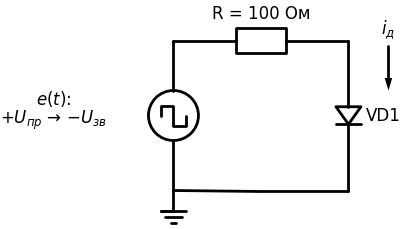

In [9]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        d.add(elm.SourceSquare().endpoints((0, 0), (0, 3)))
        d.add(elm.Label().at((-2.3, 1.5)).label('$e(t)$:\n$+U_{пр}$ → $-U_{зв}$'))
        d.add(elm.Resistor().endpoints((0, 3), (3.5, 3)).label('R = 100 Ом'))
        d.add(elm.Diode().endpoints((3.5, 3), (3.5, 0)).label('VD1', loc='bottom'))
        d.add(elm.Arrow().endpoints((4.3, 2.9), (4.3, 2.0)).label('$i_д$', loc='right'))
        d.add(elm.Line().endpoints((3.5, 0), (0, 0))); d.add(elm.Ground().at((0, 0)))

In [10]:
RECOV = {'1N4007 (p-n, випрямний 1 А)': ('DI_1N4007', 4.32e-6), '1N5819 (Шотки, 1 А)': ('D1N5819', 0.0),
         '1N4148 (p-n, імпульсний)': ('D1N4148', 3.68e-9)}

def recovery(diode='1N4007 (p-n, випрямний 1 А)', IF_mA=20, IR_mA=20):
    model, tau = RECOV[diode]
    R = 100.0
    UF, UR = IF_mA*1e-3*R + 0.8, IR_mA*1e-3*R
    t_scale = max(tau, 5e-9)
    t0, t_end = 1.0*t_scale, 3.5*t_scale + 60e-9
    c = Circuit('Reverse recovery')
    c.include(lib('diodes'))
    c.PulseVoltageSource('g', 'g', c.gnd, initial_value=UF, pulsed_value=-UR, delay_time=t0,
                         rise_time=0.5e-9, fall_time=0.5e-9, pulse_width=1, period=2)
    c.R('1', 'g', 'a', R)
    c.D('1', 'a', c.gnd, model=model)
    an = c.simulator().transient(step_time=t_end/5000, end_time=t_end, max_time=min(t_end/5000, 2e-9))
    t = np.array(an.time); ua = np.array(an['a']); i = (np.array(an['g']) - ua)/R
    ts = (t - t0)*1e9
    unit = 'нс'
    if t_end > 3e-6: ts = ts/1e3; unit = 'мкс'
    fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)
    axes[0].plot(ts, i*1e3, color='#dc2626'); axes[0].axhline(0, color='k', lw=0.6)
    axes[0].axhline(-0.1*IR_mA, color='gray', ls=':', lw=1)
    axes[0].set_ylabel('$i_д$, мА'); axes[0].set_title(f'{diode}: струм і напруга діода')
    axes[1].plot(ts, ua, color='#2563eb'); axes[1].set_ylabel('$u_д$, В'); axes[1].set_xlabel(f't, {unit}')
    # вимірювання t_rr: від перемикання до моменту, коли |i| спаде до 0,1·I_зв
    after = t > t0 + 1e-9
    k_rec = np.where(after & (i > -0.1*IR_mA*1e-3) & (np.cumsum(after & (i < -0.1*IR_mA*1e-3)) > 0))[0]
    if len(k_rec):
        trr = t[k_rec[0]] - t0
        for a in axes: a.axvspan(0, trr*(1e6 if unit == 'мкс' else 1e9), color='#fde68a', alpha=0.5)
        trr_txt = f'{trr*1e6:.3g} мкс' if trr > 1e-6 else f'{trr*1e9:.3g} нс'
        axes[0].text(trr*(1e6 if unit == 'мкс' else 1e9), -IR_mA*0.5, f'  $t_{{rr}}$ ≈ {trr_txt}', fontsize=10)
        print(f'Виміряний час відновлення (до |i| = 0,1·Iзв): t_rr ≈ {trr_txt}')
    I_F = i[np.searchsorted(t, t0) - 5]; I_R = -i[np.searchsorted(t, t0 + 2e-9)]
    print(f'Фактичні струми: Iпр = {I_F*1e3:.1f} мА, Iзв = {I_R*1e3:.1f} мА (під час розсмоктування на діоді ще ≈ +0,6 В)')
    if tau > 0:
        ts = tau*np.log(1 + I_F/I_R)
        print(f'Оцінка часу розсмоктування: t_s = τ·ln(1 + Iпр/Iзв) = {tau*1e9:.3g} нс · ln(1 + {I_F/I_R:.2f}) = '
              + (f'{ts*1e6:.3g} мкс' if ts > 1e-6 else f'{ts*1e9:.3g} нс'))
    else:
        print('Діод Шотки: заряд неосновних носіїв не накопичується, перехідний процес — перезаряд ємності переходу через R')
    plt.tight_layout(); plt.show()

interact(recovery, diode=widgets.Dropdown(options=list(RECOV), description='Діод'),
         IF_mA=widgets.IntSlider(min=5, max=50, step=5, value=20, description='$I_{пр}$, мА', continuous_update=False),
         IR_mA=widgets.IntSlider(min=5, max=50, step=5, value=20, description='$I_{зв}$, мА', continuous_update=False));

interactive(children=(Dropdown(description='Діод', options=('1N4007 (p-n, випрямний 1 А)', '1N5819 (Шотки, 1 А…

---
### ⚡ Практичне застосування: Чому в імпульсних джерелах живлення ставлять швидкі діоди

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

В імпульсному перетворювачі діод перемикається десятки–сотні тисяч разів за секунду. Під час розсмоктування через діод і ключовий транзистор тече великий зворотний струм при вже прикладеній зворотній напрузі — це **динамічні втрати** $\approx U_{зв}I_{зв}t_{rr}f$ і джерело електромагнітних завад. Тому в таких схемах замість 1N4007 ($t_{rr}$ ≈ 2–30 мкс) використовують **швидкі й надшвидкі** (fast/ultrafast recovery, $t_{rr}$ = 25–500 нс, напр. UF4007) або **діоди Шотки** (при напругах до 100–200 В), а у високовольтних — діоди Шотки на **карбіді кремнію** (SiC).

</div>

---

# Моделі діода. Розрахунок кола з діодом <a class="anchor" id="diode-models"></a>

Для розрахунку кіл діод замінюють моделлю тієї складності, якої вимагає задача:

| Модель | Пряма гілка | Коли застосовувати |
|---|---|---|
| **Ідеальний ключ** | $U = 0$ при $I > 0$; $I = 0$ при $U < 0$ | напруги в колі ≫ 1 В (мережеві випрямлячі) |
| **Ключ + джерело $U_0$** | $U = U_0 \approx 0{,}7$ В (Si), 0,3 В (Шотки, Ge) | прикидкові розрахунки 5–15 В кіл |
| **Кусково-лінійна** | $U = U_0 + r_{д}I$ | розрахунок з урахуванням струму |
| **Експоненційна (Шоклі) + $R_s$** | $I = I_S(e^{(U-IR_s)/n\varphi_T}-1)$ | точний розрахунок, SPICE |
| **Малосигнальна** | $r_д = n\varphi_T/I_0$, $C = C_б + C_{диф}$ | змінні сигнали навколо робочої точки |

Точний розв'язок нелінійного кола «джерело $E$ – резистор $R$ – діод» знаходять **графоаналітично**: робоча точка — перетин ВАХ діода з **навантажувальною прямою** $I = (E - U)/R$, що проходить через точки $(E, 0)$ і $(0, E/R)$.

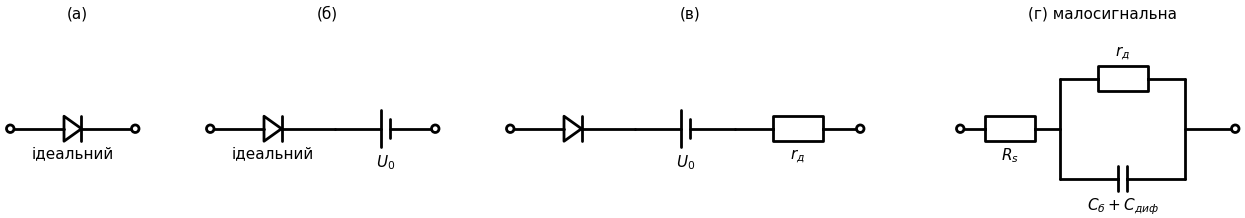

In [11]:
# Еквівалентні схеми (моделі) прямозміщеного діода
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2) as d:
        def terms(x0, x1, y=0):
            d.add(elm.Dot(open=True).at((x0, y))); d.add(elm.Dot(open=True).at((x1, y)))
        # (а) ідеальний ключ
        d.add(elm.Diode().endpoints((0, 0), (2.5, 0)).label('ідеальний', loc='bottom')); terms(0, 2.5)
        d.add(elm.Label().at((1.25, 2.2)).label('(а)'))
        # (б) ключ + U0
        d.add(elm.Diode().endpoints((4, 0), (6.5, 0)).label('ідеальний', loc='bottom'))
        d.add(elm.BatteryCell().endpoints((6.5, 0), (8.5, 0)).label('$U_0$', loc='bottom')); terms(4, 8.5)
        d.add(elm.Label().at((6.25, 2.2)).label('(б)'))
        # (в) кусково-лінійна
        d.add(elm.Diode().endpoints((10, 0), (12.5, 0)))
        d.add(elm.BatteryCell().endpoints((12.5, 0), (14.5, 0)).label('$U_0$', loc='bottom'))
        d.add(elm.Resistor().endpoints((14.5, 0), (17, 0)).label('$r_д$', loc='bottom')); terms(10, 17)
        d.add(elm.Label().at((13.5, 2.2)).label('(в)'))
        # (г) малосигнальна: Rs послідовно з (r_д || C)
        d.add(elm.Resistor().endpoints((19, 0), (21, 0)).label('$R_s$', loc='bottom'))
        d.add(elm.Line().endpoints((21, 0), (21, 1))); d.add(elm.Line().endpoints((21, 0), (21, -1)))
        d.add(elm.Resistor().endpoints((21, 1), (23.5, 1)).label('$r_д$'))
        d.add(elm.Capacitor().endpoints((21, -1), (23.5, -1)).label('$C_б + C_{диф}$', loc='bottom'))
        d.add(elm.Line().endpoints((23.5, 1), (23.5, -1))); d.add(elm.Line().endpoints((23.5, 0), (24.5, 0)))
        terms(19, 24.5)
        d.add(elm.Label().at((21.75, 2.2)).label('(г) малосигнальна'))

### ⚙️ PySpice: робоча точка діода на навантажувальній прямій <a class="anchor" id="spice-loadline"></a>

Коло: джерело $E$, резистор $R$ і діод 1N4148. ВАХ діода та точну робочу точку знайдено в ngspice; для порівняння розраховано наближені моделі (б) з $U_0 = 0{,}7$ В і (в) з $U_0 = 0{,}6$ В, $r_д = 5$ Ом. Зменшуйте $E$ до одиниць вольт і стежте, як зростає похибка спрощених моделей.

In [12]:
U_iv, I_iv = diode_dc('D1N4148', 0.0, 1.1, 0.002, include='diodes')

def load_line(E=5.0, R_ohm=470):
    c = Circuit('E-R-D'); c.include(lib('diodes'))
    c.V('e', 'e', c.gnd, E); c.R('1', 'e', 'a', R_ohm); c.D('1', 'a', c.gnd, model='D1N4148')
    op = c.simulator().operating_point()
    Ud = float(op['a'][0]); Id = (E - Ud)/R_ohm
    I_b = max(E - 0.7, 0)/R_ohm
    I_c = max(E - 0.6, 0)/(R_ohm + 5)
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(U_iv, I_iv*1e3, color='#2563eb', label='ВАХ 1N4148 (ngspice)')
    u = np.linspace(0, E, 50)
    ax.plot(u, (E - u)/R_ohm*1e3, 'k--', lw=1.3, label='навантажувальна пряма $I = (E - U)/R$')
    ax.plot(Ud, Id*1e3, 'ro', ms=8, label=f'робоча точка: {Ud:.3f} В, {Id*1e3:.2f} мА')
    ax.set_xlim(0, min(max(E, 1.2), 1.2)); ax.set_ylim(0, max(E/R_ohm*1e3*1.1, 1))
    ax.set_xlabel('U, В'); ax.set_ylabel('I, мА'); ax.legend(fontsize=9, loc='upper left')
    ax.set_title(f'E = {E} В, R = {R_ohm} Ом')
    plt.tight_layout(); plt.show()
    print(f'Точно (ngspice):             U = {Ud:.3f} В,  I = {Id*1e3:.3f} мА')
    print(f'Модель (б) U0 = 0,7 В:        I = {I_b*1e3:.3f} мА  (похибка {100*(I_b - Id)/Id:+.1f} %)')
    print(f'Модель (в) U0 = 0,6 В, rд = 5 Ом: I = {I_c*1e3:.3f} мА  (похибка {100*(I_c - Id)/Id:+.1f} %)')
    print(f'Диференціальний опір у робочій точці: rд = n·φT/I ≈ {1.92*phi_T()/Id:.2f} Ом (n = 1,92 для моделі 1N4148)')

interact(load_line, E=widgets.FloatSlider(min=0.8, max=15, step=0.1, value=5, description='E, В', continuous_update=False),
         R_ohm=widgets.IntSlider(min=50, max=2000, step=10, value=470, description='R, Ом', continuous_update=False));

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='E, В', max=15.0, min=0.8), …

---
### ✅ Питання для самоперевірки: Пробій, перехідні процеси, моделі

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Від чого залежить, яким буде пробій переходу — тунельним чи лавинним?</summary>

> **Відповідь:** Від легування бази, тобто від ширини ОПЗ: сильне легування → вузький перехід → тунелювання при $U_{проб} < 4E_g/q$; помірне → широкий перехід → лавинне множення при $U_{проб} > 6E_g/q$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому тепловий пробій, на відміну від електричного, зазвичай незворотний?</summary>

> **Відповідь:** Через додатний тепловий зворотний зв'язок температура лавиноподібно зростає, і струм шнурується в локальних ділянках, які перегріваються до плавлення металізації чи кристала.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як зміниться час розсмоктування, якщо зворотний струм збільшити вдвічі відносно прямого?</summary>

> **Відповідь:** $t_s = \tau\ln(1 + I_{пр}/I_{зв})$: при $I_{зв} = I_{пр}$ маємо $0{,}69\tau$, при $I_{зв} = 2I_{пр}$ — $\tau\ln1{,}5 = 0{,}41\tau$. Більший зворотний струм швидше «висмоктує» заряд.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Коли можна користуватися моделлю «ідеальний ключ + 0,7 В», а коли вона дає велику похибку?</summary>

> **Відповідь:** Коли напруга живлення в багато разів більша за $U_0$ і точність 5–10 % достатня. При $E$ порядку 1–2 В або при мікроамперних струмах похибка сягає десятків відсотків — потрібна експоненційна модель.

</details>

---
### 📝 Задачі для самостійного розв'язання: Вольт-амперна характеристика та пробій


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Діод має $I_S = 10^{-14}$ А, $n = 1$, $T = 300$ К. Знайдіть пряму напругу при струмі 1 мА і 10 мА.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U = \varphi_T\ln(I/I_S)$: при 1 мА $U = 0{,}02585\cdot\ln10^{11} = 0{,}655$ В; при 10 мА — на $\varphi_T\ln10 = 59{,}5$ мВ більше: 0{,}714 В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Знайдіть диференціальний опір цього діода при струмі 2 мА. Якою буде амплітуда змінного струму, якщо на діод подати змінну напругу амплітудою 5 мВ?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $r_д = \varphi_T/I = 25{,}85/2 = 12{,}9$ Ом; $I_m = U_m/r_д = 5/12{,}9 \approx 0{,}39$ мА.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Діод працює при сталому струмі 1 мА; при 25 °C пряма напруга 0,65 В, ТКН = −2 мВ/°C. Якою буде напруга при 85 °C і при −15 °C?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\Delta U = -2\cdot(85-25) = -120$ мВ → 0,53 В; при −15 °C: $\Delta U = +80$ мВ → 0,73 В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Модель 1N4007: $I_S = 76{,}9$ пА, $n = 1{,}45$, $R_s = 42$ мОм. Оцініть пряму напругу при 1 А.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U = n\varphi_T\ln(I/I_S) + IR_s = 1{,}45\cdot0{,}02585\cdot\ln(1/76{,}9\cdot10^{-12}) + 0{,}042 = 0{,}873 + 0{,}042 \approx 0{,}91$ В.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 5.** Оцініть напругу лавинного пробою кремнієвого $p^+$–$n$ переходу з легуванням бази $10^{16}$ і $10^{15}$ см⁻³.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{проб} \approx 60\,(1{,}12/1{,}1)^{1{,}5}(N_d/10^{16})^{-3/4}$: ≈ 62 В і ≈ 347 В. Зменшення легування в 10 разів підвищує напругу пробою в $10^{0,75} \approx 5{,}6$ раза.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 6.** Діод з часом життя $\tau = 4{,}3$ мкс проводив прямий струм 20 мА і перемкнувся на зворотний струм 20 мА. Оцініть час розсмоктування.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $t_s = \tau\ln(1 + I_{пр}/I_{зв}) = 4{,}3\cdot\ln2 \approx 3{,}0$ мкс.

</details>

---

## 📌 Підсумок лекції 3: Вольт-амперна характеристика діода <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Явище | Формула / ознака | Типові значення (Si) |
|---|---|---|
| Рівняння Шоклі | $I = I_S(e^{U/n\varphi_T} - 1)$ | 60 мВ на декаду при $n = 1$ |
| Диференціальний опір | $r_д = n\varphi_T/I$ | 26 Ом при 1 мА |
| ТКН прямої напруги | $dU/dT \approx -(E_g/q + 3\varphi_T - U)/T$ | ≈ −2 мВ/К |
| Зворотний струм | $I_{ген} = qn_iWS/2\tau$ | подвоюється кожні 8–10 °C |
| Тунельний пробій | $U_{проб} < 4E_g/q$, м'яке коліно | ТКН < 0 |
| Лавинний пробій | $U_{проб} > 6E_g/q$, $M = [1-(U/U_{проб})^m]^{-1}$ | ТКН > 0 |
| Час розсмоктування | $t_s = \tau\ln(1 + I_{пр}/I_{зв})$ | нс (імпульсні) – мкс (випрямні) |

**Головні висновки.** (1) Рівняння Шоклі добре описує середні струми; при малих струмах домінує рекомбінація ($n \approx 2$), при великих — високий рівень інжекції та опір бази. (2) Зворотний струм кремнієвих діодів визначає генерація в ОПЗ, і він сильно залежить від температури. (3) Електричний пробій оборотний, тепловий — руйнівний. (4) Швидкодію p-n діода обмежує накопичений заряд неосновних носіїв; діоди Шотки від цього вільні. (5) Модель діода обирають за точністю, потрібною для задачі; графоаналітичний метод навантажувальної прямої дає точну робочу точку.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 2. Електронно-дірковий (p-n) перехід](Лекція_02_Електронно-дірковий_перехід.ipynb) &nbsp;|&nbsp; [Лекція 4. Напівпровідникові діоди та їх застосування](Лекція_04_Напівпровідникові_діоди_та_їх_застосування.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*